# import

In [110]:
import os 
import keras
import numpy as np 
import tensorflow as tf
import pandas as pd
from IPython.display import clear_output as cls
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from keras.layers import  Input
from keras.callbacks import ModelCheckpoint
from keras.models import Sequential
from tensorflow.keras.utils import image_dataset_from_directory
from keras.layers import Conv2D
from keras.layers import MaxPool2D
from keras.layers import Flatten
from keras.layers import Dense 
from keras.layers import GlobalAveragePooling2D as GAP
import random
from keras.layers import Activation
from keras.layers import Dropout
from keras.models import Model
from keras.layers import  Input
from keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from keras.optimizers import Adam
import plotly.express as px
import shutil
import pathlib
from tqdm import tqdm
from typing import Tuple, List
from glob import glob
from tensorflow import image as tfi

# Prepare Data // visualization 

In [ ]:
root_path = 'chula-mosquito-classification/'

class_names = sorted(os.listdir(root_path))
len_classes = len(class_names)
Data_dis = [len(os.listdir(root_path + name)) for name in class_names]

aegypti = len(os.listdir('chula-mosquito-classification/Ae-aegypti/'))
albopictus = len(os.listdir('chula-mosquito-classification/Ae-albopictus/'))
vexans = len(os.listdir('chula-mosquito-classification/Ae-vexans/'))
tessellatus = len(os.listdir('chula-mosquito-classification/An-tessellatus/'))
quinquefasciatus = len(os.listdir('chula-mosquito-classification/Cx-quinquefasciatus/'))
vishnui = len(os.listdir('chula-mosquito-classification/Cx-vishnui/'))
Misc = len(os.listdir('chula-mosquito-classification/Misc/'))


total = Misc + vishnui + quinquefasciatus + tessellatus + vexans + albopictus + aegypti
print(f'Lengh of : \aegypti: {aegypti}  \nalbopictus: {albopictus} \nvexans: {vexans} \ntessellatus: {tessellatus} \nquinquefasciatus: {quinquefasciatus}\nvishnui: {vishnui} \nMisc : {Misc}')
print(f'We have {total} Image')
print(f"Total Number of Classes : {len_classes} \nClass Names : {class_names}")

Lengh of : egypti: 10142  
albopictus: 8866 
vexans: 8140 
tessellatus: 7205 
quinquefasciatus: 9438
vishnui: 8217 
Misc : 9384
We have 61392 Image
Total Number of Classes : 7 
Class Names : ['Ae-aegypti', 'Ae-albopictus', 'Ae-vexans', 'An-tessellatus', 'Cx-quinquefasciatus', 'Cx-vishnui', 'Misc']


In [3]:
def count_plot(x, title, xlabel, ylabel, width, length, order = None, rotation=False, palette='winter'):
    plt.figure(figsize=(width,length))
    sns.countplot(x = x, palette=palette, order = order)
    plt.title(title, fontsize=25)
    if rotation:
        plt.xticks(rotation = 'vertical')
    plt.xlabel(xlabel, fontsize=20)
    plt.ylabel(ylabel, fontsize=20)
    plt.show()
    
def show_image(dir):
    plt.figure(figsize=(10,5))
    for i in range(6):
        plt.subplot(2,7,i+1)
        img = random.choice(os.listdir(dir))
        img = tf.keras.utils.load_img(os.path.join(dir,img))
        plt.subplots_adjust(hspace=0.3)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()

In [4]:
fig = px.pie(names=class_names, values=Data_dis,
             title="Training Class Distribution", hole=0.3)
fig.update_layout({'title':{'x':0.45}})
fig.show()

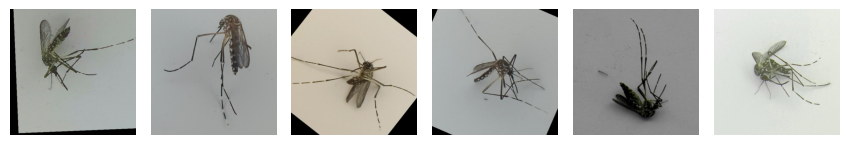

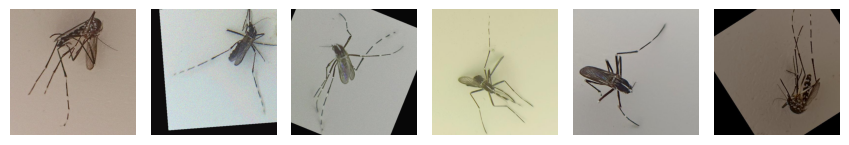

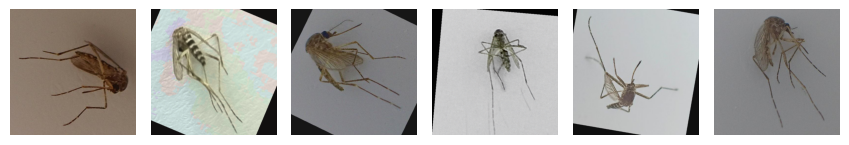

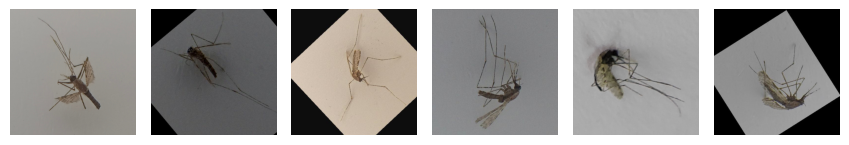

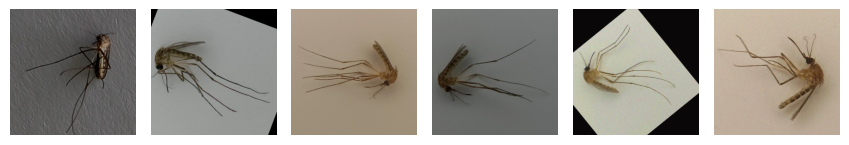

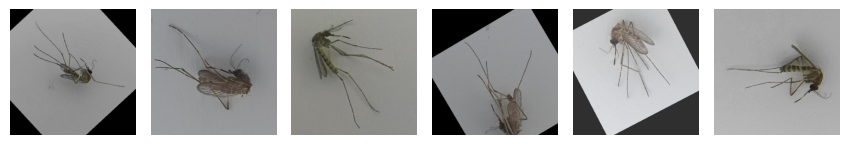

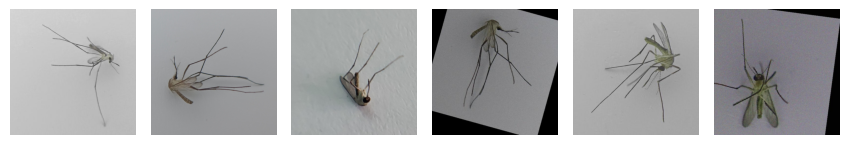

In [ ]:
show_image("chula-mosquito-classification/Ae-aegypti/")
show_image("chula-mosquito-classification/Ae-albopictus/")
show_image("chula-mosquito-classification/Ae-vexans/")
show_image("chula-mosquito-classification/An-tessellatus/")
show_image("chula-mosquito-classification/Cx-quinquefasciatus/")
show_image("chula-mosquito-classification/Cx-vishnui/")
show_image("chula-mosquito-classification/Misc")

In [3]:
IMG_SIZE = 150
BATCH_SIZE = 32

In [4]:
datagen = ImageDataGenerator(rescale=1/255.,
                             rotation_range=15,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             validation_split=0.15)

In [5]:
train_ds0 = datagen.flow_from_directory(root_path, 
                                       target_size=(IMG_SIZE,IMG_SIZE), 
                                       shuffle=True,
                                       class_mode='categorical', 
                                       batch_size=BATCH_SIZE,
                                       subset='training') 
test_ds0 = datagen.flow_from_directory(root_path,
                                       target_size=(IMG_SIZE,IMG_SIZE),
                                       class_mode='categorical',
                                       shuffle=True, 
                                       batch_size=BATCH_SIZE,
                                       subset='validation')

Found 52187 images belonging to 7 classes.
Found 9205 images belonging to 7 classes.


In [9]:
train_ds0.class_indices.keys()

dict_keys(['Ae-aegypti', 'Ae-albopictus', 'Ae-vexans', 'An-tessellatus', 'Cx-quinquefasciatus', 'Cx-vishnui', 'Misc'])

data batch shape: (32, 150, 150, 3)
label batch shape: (32, 7)


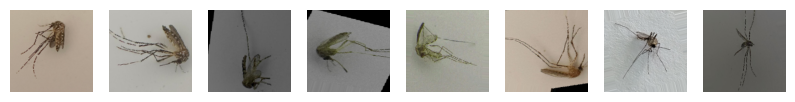

In [14]:
for data_batch, label_batch in train_ds0:
    print('data batch shape:', data_batch.shape)
    print('label batch shape:', label_batch.shape)
    

    # Show five random examples of the loaded batch
    fig, axes = plt.subplots(1, 8, figsize=(10,5))
    for i, ax in enumerate(axes):
        ax.imshow(data_batch[i])
        ax.set_axis_off()
    break

plt.show()

# build model

##  Classification head

In [11]:
conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3))

conv_base.trainable = False

58889256/58889256 [==============================] - 0s 0us/step


In [12]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [14]:
inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = conv_base(inp)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(1512, activation='relu')(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(900, activation='relu')(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(len_classes, activation='softmax')(x)

model = Model(inputs=inp, outputs=out)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 global_average_pooling2d_1   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_3 (Dense)             (None, 1512)              775656    
                                                                 
 dropout_2 (Dropout)         (None, 1512)              0         
                                                                 
 dense_4 (Dense)             (None, 900)               1361700   
                                                           

In [15]:
model.compile(loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"])

In [16]:
history = model.fit(
    train_ds0,
    epochs=10)

Epoch 1/10
1631/1631 [==============================] - 895s 544ms/step - loss: 1.2929 - accuracy: 0.5072
Epoch 2/10
1631/1631 [==============================] - 572s 351ms/step - loss: 1.0699 - accuracy: 0.6016
Epoch 3/10
1631/1631 [==============================] - 544s 333ms/step - loss: 0.9988 - accuracy: 0.6292
Epoch 4/10
1631/1631 [==============================] - 543s 333ms/step - loss: 0.9416 - accuracy: 0.6518
Epoch 5/10
1631/1631 [==============================] - 538s 330ms/step - loss: 0.9035 - accuracy: 0.6678
Epoch 6/10
1631/1631 [==============================] - 539s 331ms/step - loss: 0.8760 - accuracy: 0.6758
Epoch 7/10
1631/1631 [==============================] - 538s 330ms/step - loss: 0.8498 - accuracy: 0.6862
Epoch 8/10
1631/1631 [==============================] - 539s 330ms/step - loss: 0.8214 - accuracy: 0.6960
Epoch 9/10
1631/1631 [==============================] - 540s 331ms/step - loss: 0.7933 - accuracy: 0.7074
Epoch 10/10
1631/1631 [=======================

## Fine-tuninng


In [17]:
# Freeze all layers, except the last conv block (last 4 layers)
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False
    
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 global_average_pooling2d_1   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_3 (Dense)             (None, 1512)              775656    
                                                                 
 dropout_2 (Dropout)         (None, 1512)              0         
                                                                 
 dense_4 (Dense)             (None, 900)               1361700   
                                                           

In [18]:
model.compile(loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-5),
    metrics=["accuracy"])


In [19]:
history1 = model.fit(
    train_ds0,
    epochs=10)

Epoch 1/10
1631/1631 [==============================] - 544s 332ms/step - loss: 0.5476 - accuracy: 0.8052
Epoch 2/10
1631/1631 [==============================] - 546s 335ms/step - loss: 0.3798 - accuracy: 0.8639
Epoch 3/10
1631/1631 [==============================] - 548s 336ms/step - loss: 0.3022 - accuracy: 0.8943
Epoch 4/10
1631/1631 [==============================] - 545s 334ms/step - loss: 0.2414 - accuracy: 0.9152
Epoch 5/10
1631/1631 [==============================] - 555s 340ms/step - loss: 0.2100 - accuracy: 0.9252
Epoch 6/10
1631/1631 [==============================] - 544s 333ms/step - loss: 0.1785 - accuracy: 0.9374
Epoch 7/10
1631/1631 [==============================] - 541s 332ms/step - loss: 0.1545 - accuracy: 0.9465
Epoch 8/10
1631/1631 [==============================] - 543s 333ms/step - loss: 0.1373 - accuracy: 0.9528
Epoch 9/10
1631/1631 [==============================] - 543s 333ms/step - loss: 0.1198 - accuracy: 0.9587
Epoch 10/10
1631/1631 [=======================

In [22]:
accuracy1 = history.history["accuracy"]
accuracy2 = history1.history["accuracy"]

loss1 = history.history["loss"]
loss2 = history1.history["loss"]


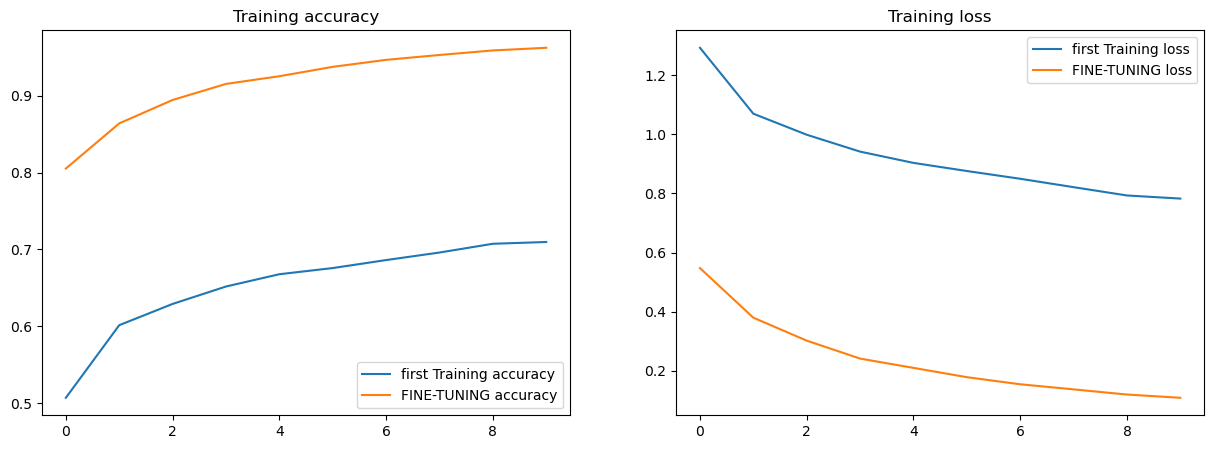

In [30]:


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(accuracy1, label="first Training accuracy")
axes[0].plot(accuracy2, label="FINE-TUNING accuracy")
axes[0].set_title("Training accuracy")
axes[0].legend()

axes[1].plot(loss1, label="first Training loss")
axes[1].plot(loss2, label="FINE-TUNING loss")
axes[1].set_title("Training loss")
axes[1].legend()
plt.show()

In [ ]:
model.evaluate(test_ds0)

1/1 [==============================] - 0s 30ms/step


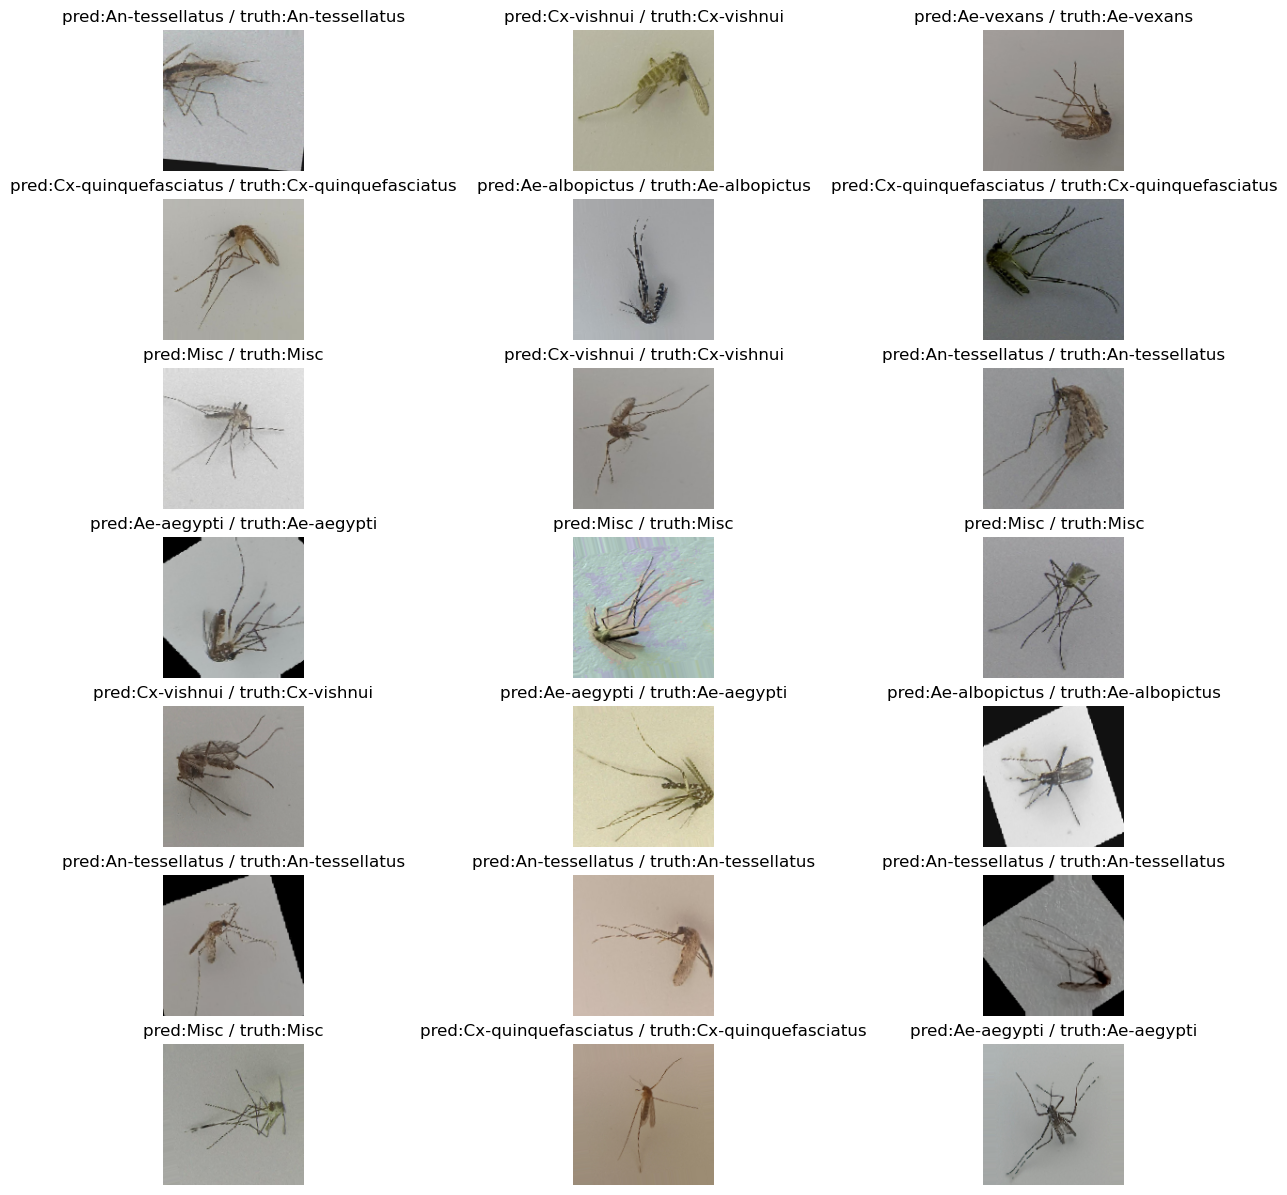

In [104]:


test_x, test_y = train_ds0.__getitem__(5)

preds = model.predict(test_x)

plt.figure(figsize=(15, 15))
for i in range(21):
    plt.subplot(7, 3, i+1)
    plt.title('pred:%s / truth:%s' % (class_names[np.argmax(preds[i])], class_names[np.argmax(test_y[i])]))
    plt.imshow(test_x[i])
    plt.axis('off')

In [55]:
from tensorflow.keras.utils import load_img ,img_to_array
def predict_image(image_path):
    img = load_img(image_path, target_size=(224,224,3))
    plt.imshow(img)
    plt.show()
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    images = np.vstack([x])
    pred = model.predict(images, batch_size=32)
    print("Actual: "+(image_path.split("/")[-2]).split("_")[0])
    print("Predicted: "+class_names[np.argmax(pred)])

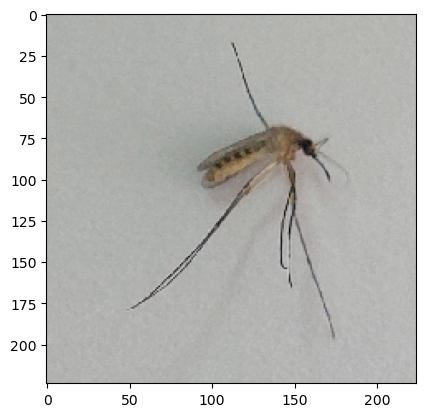

1/1 [==============================] - 0s 22ms/step
Actual: Cx-quinquefasciatus
Predicted: Cx-quinquefasciatus


In [ ]:
predict_image("chula-mosquito-classification/Cx-quinquefasciatus")

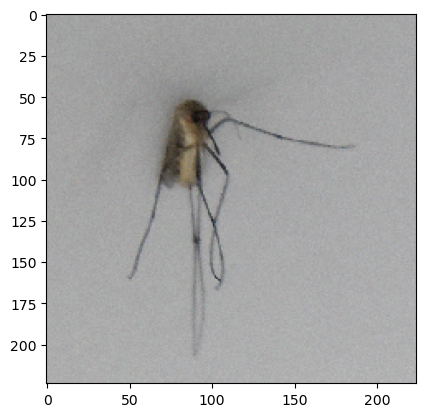

1/1 [==============================] - 0s 22ms/step
Actual: Cx-quinquefasciatus
Predicted: Cx-quinquefasciatus


In [ ]:
predict_image("chula-mosquito-classification/Cx-quinquefasciatus/Galaxy-A52s_Cx-quinquefasciatus_s01_l2_t2_A2.png")

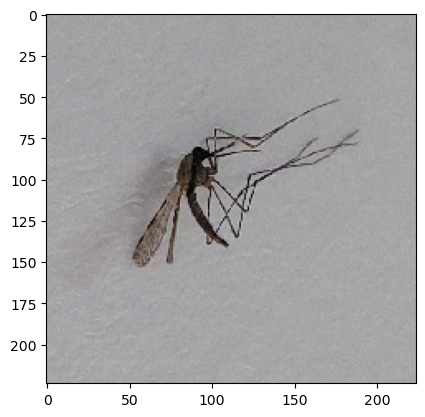

1/1 [==============================] - 0s 23ms/step
Actual: An-tessellatus
Predicted: Cx-quinquefasciatus


In [ ]:
predict_image("chula-mosquito-classification/An-tessellatus/Galaxy-A52s_An-tessellatus_s06_l1_t2_A6.png")

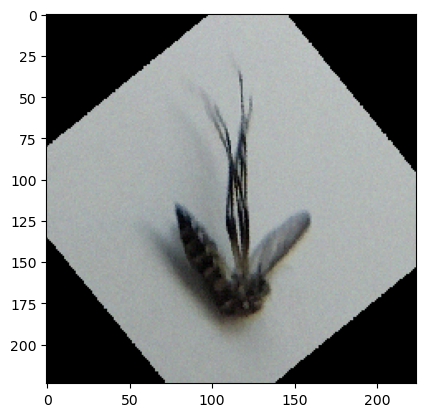

1/1 [==============================] - 0s 22ms/step
Actual: Ae-aegypti
Predicted: Ae-aegypti


In [ ]:
predict_image("chula-mosquito-classification/Ae-aegypti/Galaxy-A52s_Ae-aegypti_s01_l1_t3_A6.png")

### Image Augmentation

In [92]:
image_path = r'archive (13).zip'

In [ ]:
file = 'archive (13).zip'
df = pd.read_csv

In [94]:
print(file)

archive (13).zip


In [37]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size
IMG_SIZE = 224
BATCH_SIZE = 32

# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,

    shear_range=0.2,
    zoom_range=0.2,

    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)



Advanced Augmentation

In [89]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2),

    layers.RandomTranslation(0.1, 0.1)

])

In [90]:
model = tf.keras.Sequential([

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(6, activation='softmax')  # 6 mosquito species
])

Training the Model

In [70]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Saving the Model

In [71]:
model.save("mosquito_species_model.h5")

In [ ]:
import matplotlib.pyplot as plt

sample_batch = next
images = sample_batch

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.show
    plt.axis("off")

plt.show()

In [88]:
import matplotlib.pyplot as plt

sample_batch = next
images = sample_batch

plt.figure(figsize=(10,10))



<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

### Confusion matrix

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

In [118]:
cm = confusion_matrix
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

In [143]:
print(cm)

<function confusion_matrix at 0x0000027902F3EE80>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# True labels from test dataset
y_true = np.array([0,1,2,0,1,2,0,1,2])

# Model predictions
y_pred = np.array([0,1,2,1,1,2,0,0,2])

# Class names
class_names = ['Aedes', 'Anopheles', 'Culex']

In [7]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[2 1 0]
 [1 2 0]
 [0 0 3]]


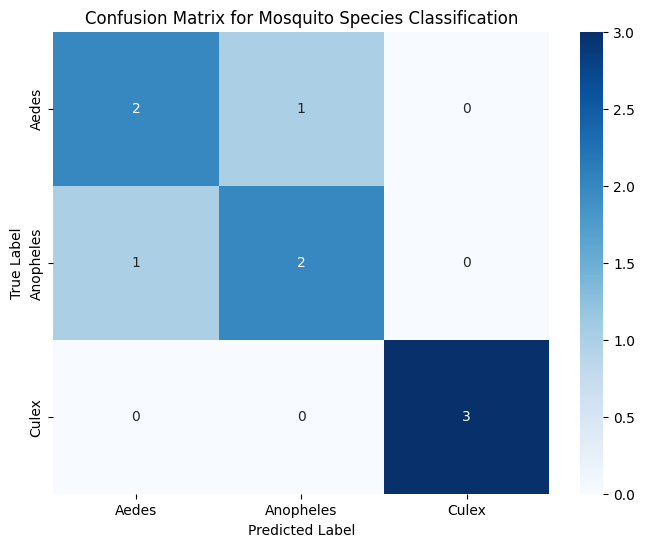

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Mosquito Species Classification")

plt.show()

In [9]:
report = classification_report(y_true, y_pred, target_names=class_names)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

       Aedes       0.67      0.67      0.67         3
   Anopheles       0.67      0.67      0.67         3
       Culex       1.00      1.00      1.00         3

    accuracy                           0.78         9
   macro avg       0.78      0.78      0.78         9
weighted avg       0.78      0.78      0.78         9



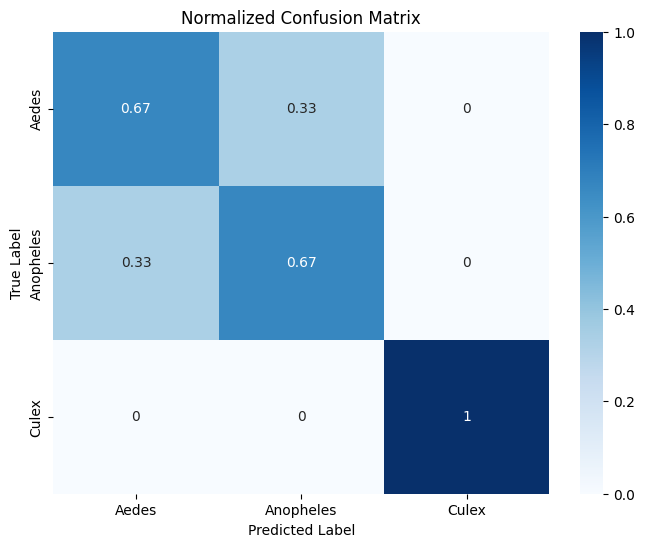

In [10]:
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_percent,
    annot=True,
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")

plt.show()

### CNN Model

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [36]:
#Image Preprocessing and Augmentation
train_datagen = ('rescale=1./255',
    'rotation_range=20',
    'zoom_range=0.2',
    'horizontal_flip=True',
    'validation_split=0.2'
)

train_data = ('DatasetAfricaMalaria.csv',
    'target_size=(224,224)',
    'batch_size=32',
    'class_mode="categorical"',
    'subset="training"'
)

val_data = ('DatasetAfricaMalaria.csv',
    'target_size=(224,224)',
    'batch_size=32',
    'class_mode="categorical"',
    'subset="validation"'
)

In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

# Second Convolution Layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

# Third Convolution Layer
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(3,activation='softmax'))

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history = ('train_data',
    'epochs=20',
    'validation_data=val_data'
)

In [49]:
model.save("mosquito_species_model.h5")

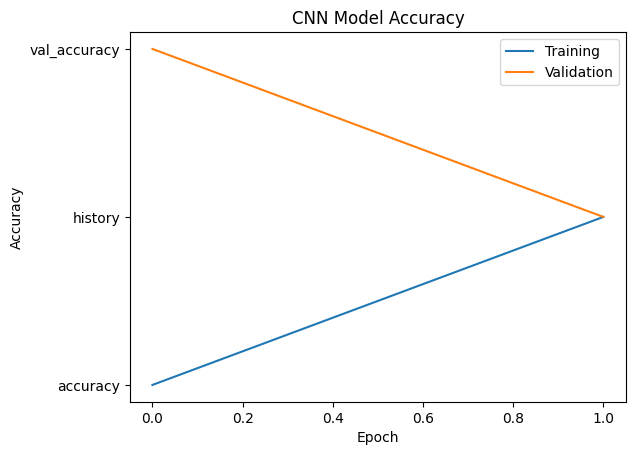

In [65]:
#Visual of training Accuracy
plt.plot(['accuracy','history'])
plt.plot(['val_accuracy','history'])

plt.title("CNN Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Training","Validation"])

plt.show()

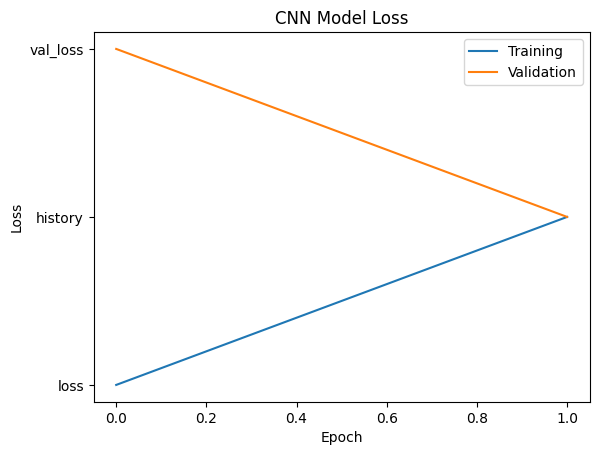

In [63]:
plt.plot(['loss','history'])
plt.plot(['val_loss','history'])

plt.title("CNN Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Training","Validation"])

plt.show()

In [73]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="cnn_model_structure.png",
    show_shapes=True,
    show_layer_names=True
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


### LSTM Model

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [75]:
# X_train: shape (num_samples, timesteps, features)
# y_train: categorical labels
# X_val, y_val: validation data

# Example dummy data:
num_classes = 3
timesteps = 50  # e.g., sequence length
features = 64   # e.g., feature vector size

# Replace these with your real dataset
X_train = np.random.rand(100, timesteps, features)
y_train = np.random.randint(0, num_classes, 100)
y_train = to_categorical(y_train, num_classes=num_classes)

X_val = np.random.rand(20, timesteps, features)
y_val = np.random.randint(0, num_classes, 20)
y_val = to_categorical(y_val, num_classes=num_classes)

In [76]:
model = Sequential()

# LSTM layer
model.add(LSTM(128, input_shape=(timesteps, features), return_sequences=False))
model.add(Dropout(0.5))

# Fully connected output layer
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,203 (387.51 KB)

 Trainable params: 99,203 (387.51 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 245ms/step - accuracy: 0.3000 - loss: 1.1512 - val_accuracy: 0.4000 - val_loss: 1.1583
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.3500 - loss: 1.1529 - val_accuracy: 0.3500 - val_loss: 1.1143
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.3400 - loss: 1.1248 - val_accuracy: 0.4500 - val_loss: 1.0965
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.3900 - loss: 1.0971 - val_accuracy: 0.3500 - val_loss: 1.1041
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.3300 - loss: 1.1453 - val_accuracy: 0.3500 - val_loss: 1.1290
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.4200 - loss: 1.0780 - val_accuracy: 0.3500 - val_loss: 1.1226
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4600 - loss: 1.0756 - val_accuracy: 0.4500 - val_loss: 1.1096
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4100 - loss: 1.0355 - val_accuracy: 0.4000 - val_loss: 1.12

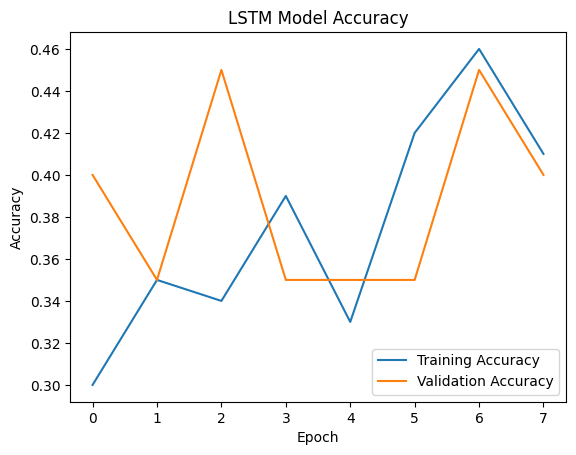

In [78]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

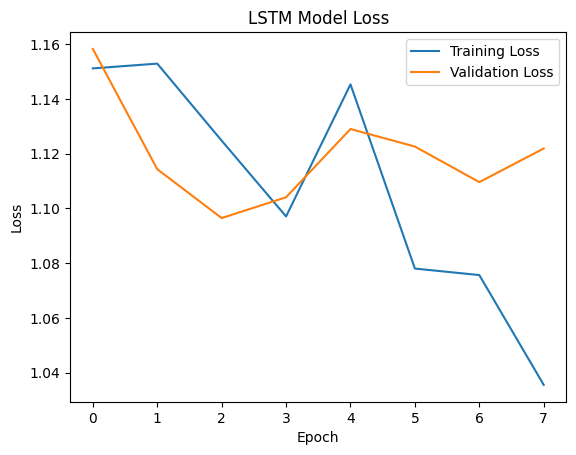

In [79]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [80]:
#Saving the model
model.save("lstm_mosquito_model.h5")

In [81]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=["Aedes","Anopheles","Culex"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
Confusion Matrix:
 [[1 6 0]
 [0 6 0]
 [2 3 2]]
Classification Report:
               precision    recall  f1-score   support

       Aedes       0.33      0.14      0.20         7
   Anopheles       0.40      1.00      0.57         6
       Culex       1.00      0.29      0.44         7

    accuracy                           0.45        20
   macro avg       0.58      0.48      0.41        20
weighted avg       0.59      0.45      0.40        20



### Random forest

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from joblib import dump, load

In [83]:
# X: features extracted from images (flattened or CNN features)
# y: labels (0 = Aedes, 1 = Anopheles, 2 = Culex)

# Example dummy data for demonstration
num_samples = 200
num_features = 512  # e.g., CNN feature vector size

X = np.random.rand(num_samples, num_features)
y = np.random.randint(0, 3, num_samples)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [84]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [85]:
#Predict and Evaluate
y_pred = rf_model.predict(X_test)

# Classification report
class_names = ["Aedes", "Anopheles", "Culex"]
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Classification Report:
               precision    recall  f1-score   support

       Aedes       0.57      0.31      0.40        13
   Anopheles       0.42      0.42      0.42        12
       Culex       0.52      0.73      0.61        15

    accuracy                           0.50        40
   macro avg       0.50      0.49      0.48        40
weighted avg       0.51      0.50      0.48        40

Confusion Matrix:
 [[ 4  5  4]
 [ 1  5  6]
 [ 2  2 11]]


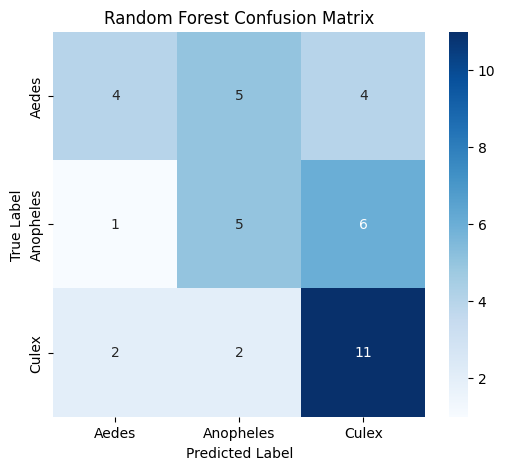

In [87]:
#Visualize Confusion mtrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [88]:
# Save model
dump(rf_model, "rf_mosquito_model.joblib")

# Load model later
# rf_model = load("rf_mosquito_model.joblib")

['rf_mosquito_model.joblib']

### Image Augmentaion

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [3]:
#Image augmentation generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,        # rotate images
    width_shift_range=0.2,    # horizontal movement
    height_shift_range=0.2,   # vertical movement
    shear_range=0.2,          # shear transformation
    zoom_range=0.2,           # zoom in/out
    horizontal_flip=True,     # flip image horizontally
    fill_mode='nearest'
)

In [4]:
train_data = ("archive (13).zip")

In [5]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "archive (13).zip"
img = (img_path)
x = (img)
x = (1,)

i = 0
plt.figure(figsize=(10,10))


plt.show()

<Figure size 1000x1000 with 0 Axes>

In [6]:
save_datagen = ImageDataGenerator(
    rotation_range=40,
    zoom_range=0.2,
    horizontal_flip=True
)

save_datagen = (x)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [16]:
img_path = "archive (13).zip"

img = (img_path, (224,224))
img_array = (img)
img_array = img_array

In [17]:
datagen = ImageDataGenerator(
    rotation_range=40,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    fill_mode='nearest'
)

In [26]:
plt.figure(figsize=(10,10))

i = 0


plt.suptitle("Mosquito Image Augmentation Examples")
plt.show()

<Figure size 1000x1000 with 0 Axes>